# ICBHI — Notebook 5 : Patient-level CV + Focal Loss + Augmentation

**Fixes vs NB4:**
- CV split au niveau patient (plus de leakage) — CV score refletera vraiment le test
- Augmentation offline pre-calculee avant l'entrainement (epochs rapides)
- Threshold tuning uniquement si CV sans leakage confirme le gain

| Cell | Contenu |
|------|---------|
| 1 | Env check |
| 2 | Install + clone repo |
| 3 | Restore checkpoints + constants |
| 4 | Preprocessing |
| 5 | Push checkpoints |
| 6 | **Training** — patient-level CV + Focal Loss + augmentation offline |
| 7 | Learning curves |
| 8 | Test inference |
| 9 | Threshold tuning sur CV propre |
| 10 | Metriques completes + ablation table |
| 11 | Error analysis + visualisations |

In [1]:
import torch, os, sys
print('=' * 55)
print('ENVIRONMENT CHECK')
print('=' * 55)
print(f'GPU available : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU name      : {torch.cuda.get_device_name(0)}')
    print(f'GPU memory    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
print(f'Python  : {sys.version}')
print(f'PyTorch : {torch.__version__}')
print('\n/kaggle/input/ contents:')
!ls /kaggle/input/

ENVIRONMENT CHECK
GPU available : True
GPU name      : Tesla T4
GPU memory    : 15.6 GB
Python  : 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
PyTorch : 2.10.0+cu128

/kaggle/input/ contents:
datasets


In [2]:
!pip install -q librosa soundfile 'transformers>=4.30.0' tqdm seaborn
import os, sys
REPO_DIR = '/kaggle/working/ICBHI-AST-SAM'
if not os.path.exists(REPO_DIR):
    !git clone https://github.com/Atakanisik/ICBHI-AST-SAM.git {REPO_DIR}
    print('Repo cloned.')
else:
    print('Repo already present.')
os.chdir(REPO_DIR)
sys.path.insert(0, REPO_DIR)
print(f'Working dir : {os.getcwd()}')

Cloning into '/kaggle/working/ICBHI-AST-SAM'...
remote: Enumerating objects: 34, done.
remote: Counting objects: 100% (34/34), done.
remote: Compressing objects: 100% (31/31), done.
remote: Total 34 (delta 12), reused 8 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (34/34), 17.07 KiB | 5.69 MiB/s, done.
Resolving deltas: 100% (12/12), done.
Repo cloned.
Working dir : /kaggle/working/ICBHI-AST-SAM


In [3]:
import shutil, os, torch, numpy as np

PERSIST_DIR    = '/kaggle/input/datasets/eyakhlifi21/icbhi-checkpoints-4'  
CHECKPOINT_DIR = '/kaggle/working/ICBHI-AST-SAM/checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

for fname in ['best_model.pth', 'checkpoint_latest.pth', 'history.json',
              'patient_ids_train.npy']:
    src = os.path.join(PERSIST_DIR, fname)
    dst = os.path.join(CHECKPOINT_DIR, fname)
    if os.path.exists(src) and not os.path.exists(dst):
        shutil.copy(src, dst)
        print(f'Restored: {fname}  ({os.path.getsize(dst)/1e6:.1f} MB)')
    elif os.path.exists(dst):
        print(f'Already present: {fname}')
    else:
        print(f'Not found (fresh start): {fname}')

BEST_CKPT    = os.path.join(CHECKPOINT_DIR, 'best_model.pth')
LATEST_CKPT  = os.path.join(CHECKPOINT_DIR, 'checkpoint_latest.pth')
HISTORY_FILE = os.path.join(CHECKPOINT_DIR, 'history.json')
NPZ_PATH     = '/kaggle/working/ICBHI-AST-SAM/icbhi_ast_16k_8s_metadata.npz'
CKPT_DIR     = CHECKPOINT_DIR
CLASS_NAMES  = ['Normal', 'Crackle', 'Wheeze', 'Both']
DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'\nDevice : {DEVICE}')
print(f'Best model exists: {os.path.exists(BEST_CKPT)}')

def icbhi_score(labels, preds):
    se, sp = [], []
    for c in range(4):
        tp = ((preds==c)&(labels==c)).sum()
        fn = ((preds!=c)&(labels==c)).sum()
        tn = ((preds!=c)&(labels!=c)).sum()
        fp = ((preds==c)&(labels!=c)).sum()
        se.append(tp/(tp+fn+1e-9))
        sp.append(tn/(tn+fp+1e-9))
    return (np.mean(se)+np.mean(sp))/2

Restored: best_model.pth  (344.8 MB)
Restored: checkpoint_latest.pth  (344.8 MB)
Restored: history.json  (0.0 MB)
Restored: patient_ids_train.npy  (0.1 MB)

Device : cuda
Best model exists: True


In [12]:
import os, numpy as np

DATA_DIR = None
for root, dirs, files in os.walk('/kaggle/input/'):
    wavs = [f for f in files if f.endswith('.wav')]
    if len(wavs) > 100:
        DATA_DIR = root
        print(f'Found dataset: {root}  ({len(wavs)} .wav files)')
        break

if DATA_DIR is None:
    raise RuntimeError('Dataset not found in /kaggle/input/. Attach the ICBHI dataset.')

os.makedirs('data', exist_ok=True)
if not os.path.exists('data/ICBHI_final_database'):
    os.symlink(DATA_DIR, 'data/ICBHI_final_database')
    print('Symlink created: data/ICBHI_final_database')

all_files   = sorted([f.replace('.wav','') for f in os.listdir(DATA_DIR) if f.endswith('.wav')])
patient_ids = sorted(set([f.split('_')[0] for f in all_files]))
np.random.seed(42)
test_patients = set(np.random.choice(patient_ids, int(len(patient_ids)*0.4), replace=False))
split_lines   = [f"{f}\t{'test' if f.split('_')[0] in test_patients else 'train'}" for f in all_files]
with open('data/ICBHI_Challenge_train_test.txt', 'w') as fh:
    fh.write('\n'.join(split_lines))
print(f'Split file: {sum(1 for l in split_lines if "train" in l)} train / {sum(1 for l in split_lines if "test" in l)} test')

if not os.path.exists(NPZ_PATH):
    print('Running preprocess.py...')
    !python /kaggle/working/ICBHI-AST-SAM/preprocess.py
else:
    print(f'NPZ already exists: {NPZ_PATH}')

raw = np.load(NPZ_PATH)
# Save patient ID per CYCLE (not per file) — needed for patient-level CV split
# Strategy: replay preprocess order by reading the split file and the NPZ metadata.
# Check if NPZ already has this info
raw_keys = list(raw.keys())
print(f'NPZ keys: {raw_keys}')

if 'patient_train' in raw_keys:
    # Lucky — preprocess.py already saved it
    print('patient_train found in NPZ — no extra work needed.')
else:
    # Reconstruct: read split file, count cycles per file using the annotation file
    # ICBHI annotation file: each line = one cycle from one recording
    ANNOT_DIR = DATA_DIR   # same folder as .wav files
    train_files_ordered = [l.split('\t')[0] for l in split_lines if 'train' in l]

    patient_ids_per_cycle = []
    for fname in train_files_ordered:
        # Count annotation lines for this file = number of cycles
        annot_path = os.path.join(ANNOT_DIR, fname + '.txt')
        if os.path.exists(annot_path):
            with open(annot_path) as af:
                n_cycles = sum(1 for line in af if line.strip())
        else:
            # fallback: assume 1 cycle per file (conservative)
            n_cycles = 1
        pid = fname.split('_')[0]
        patient_ids_per_cycle.extend([pid] * n_cycles)

    patient_ids_per_cycle = np.array(patient_ids_per_cycle)

    # Trim or pad to match X_train length
    n = len(raw['X_train'])
    if len(patient_ids_per_cycle) >= n:
        patient_ids_per_cycle = patient_ids_per_cycle[:n]
    else:
        # If shorter (some files had no annotation), warn and pad with unknown
        print(f'WARNING: got {len(patient_ids_per_cycle)} cycle IDs for {n} cycles — check annotation files')
        pad = np.array(['unknown'] * (n - len(patient_ids_per_cycle)))
        patient_ids_per_cycle = np.concatenate([patient_ids_per_cycle, pad])

    np.save(os.path.join(CHECKPOINT_DIR, 'patient_ids_train.npy'), patient_ids_per_cycle)
    print(f'Saved {CHECKPOINT_DIR}/patient_ids_train.npy')
    print(f'Saved patient_ids_train.npy — {len(patient_ids_per_cycle)} entries for {n} cycles')
    print(f'Unique patients in train cycles: {len(np.unique(patient_ids_per_cycle))}')
    
print(f'X_train : {raw["X_train"].shape}')
print(f'X_test  : {raw["X_test"].shape}')
print(f'Feature shape (1 sample) : {raw["X_train"][0].shape}')
print(f'Feature ndim : {raw["X_train"][0].ndim}')
print('\nClass distribution train:')
for i, n in enumerate(CLASS_NAMES):
    cnt = (raw['y_train']==i).sum()
    print(f'  {n:<9}: {cnt:>4}  ({cnt/len(raw["y_train"])*100:.1f}%)')

Found dataset: /kaggle/input/datasets/eyakhlifi21/icbhi-data/ICBHI_final_database  (920 .wav files)
Split file: 638 train / 282 test
NPZ already exists: /kaggle/working/ICBHI-AST-SAM/icbhi_ast_16k_8s_metadata.npz
NPZ keys: ['X_train', 'y_train', 'device_train', 'X_test', 'y_test', 'device_test']
Saved /kaggle/working/ICBHI-AST-SAM/checkpoints/patient_ids_train.npy
Saved patient_ids_train.npy — 4540 entries for 4540 cycles
Unique patients in train cycles: 76
X_train : (4540, 128000)
X_test  : (2358, 128000)
Feature shape (1 sample) : (128000,)
Feature ndim : 1

Class distribution train:
  Normal   : 2302  (50.7%)
  Crackle  : 1264  (27.8%)
  Wheeze   :  637  (14.0%)
  Both     :  337  (7.4%)


In [5]:
import os
print('Files to push:')
for f in os.listdir(CHECKPOINT_DIR):
    fp = os.path.join(CHECKPOINT_DIR, f)
    print(f'  {f}  ({os.path.getsize(fp)/1e6:.1f} MB)')
!kaggle datasets version -p {CHECKPOINT_DIR} -m 'nb5 epoch update' 2>/dev/null || \
    echo 'Kaggle CLI non configure — uploader manuellement dans le dataset UI.'

Files to push:
  patient_ids_train.npy  (0.1 MB)
  .gitkeep  (0.0 MB)
  history.json  (0.0 MB)
  checkpoint_latest.pth  (344.8 MB)
  best_model.pth  (344.8 MB)
Metadata file not found: dataset-metadata.json
Kaggle CLI non configure — uploader manuellement dans le dataset UI.


In [7]:
import shutil, os

SRC = "/kaggle/input/datasets/eyakhlifi21/icbhi-checkpoints-4"
DST = "/kaggle/working/ICBHI-AST-SAM/checkpoints"

os.makedirs(DST, exist_ok=True)

for fname in os.listdir(SRC):
    shutil.copy(os.path.join(SRC, fname), os.path.join(DST, fname))
    size = os.path.getsize(os.path.join(DST, fname))
    print(f"Copied: {fname}  ({size/1e6:.1f} MB)")

print(f"\nDone. Files in {DST}:")
for f in os.listdir(DST):
    print(f"  {f}")

Copied: test_labels.npy  (0.0 MB)
Copied: test_preds.npy  (0.0 MB)
Copied: best_model.pth  (344.8 MB)
Copied: history.json  (0.0 MB)
Copied: gitkeep  (0.0 MB)
Copied: patient_ids_train.npy  (0.1 MB)
Copied: test_probs.npy  (0.0 MB)
Copied: checkpoint_latest.pth  (344.8 MB)

Done. Files in /kaggle/working/ICBHI-AST-SAM/checkpoints:
  patient_ids_train.npy
  test_probs.npy
  .gitkeep
  history.json
  test_preds.npy
  checkpoint_latest.pth
  best_model.pth
  gitkeep
  test_labels.npy


In [8]:
import os, sys, json, numpy as np, torch, torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, WeightedRandomSampler, Dataset
from tqdm import tqdm

sys.path.insert(0, '/kaggle/working/ICBHI-AST-SAM')
from transformers import ASTFeatureExtractor
from src.dataset import ASTDataset
from src.model   import CustomAST
from src.sam     import SAM

# ── Config ────────────────────────────────────────────────────────────────
EPOCHS      = 20
BATCH_SIZE  = 8
LR          = 1e-5
PATIENCE    = 5
FOCAL_GAMMA = 1.5
CV_PATIENT_RATIO = 0.30   # 30% of PATIENTS go to CV (not recordings)

# ── Focal Loss ────────────────────────────────────────────────────────────
class FocalLoss(nn.Module):
    def __init__(self, gamma=1.5, alpha=None, reduction='mean'):
        super().__init__()
        self.gamma = gamma; self.alpha = alpha; self.reduction = reduction

    def forward(self, logits, targets):
        ce   = F.cross_entropy(logits, targets, weight=self.alpha, reduction='none')
        pt   = torch.exp(-ce)
        loss = (1 - pt) ** self.gamma * ce
        return loss.mean() if self.reduction == 'mean' else loss.sum() if self.reduction == 'sum' else loss

# ── Step 1: Load NPZ ──────────────────────────────────────────────────────
print('Loading NPZ...')
raw        = np.load(NPZ_PATH)
X_trainall = raw['X_train']
y_trainall = raw['y_train']
d_trainall = raw['device_train']
X_test     = raw['X_test']
y_test     = raw['y_test']
d_test     = raw['device_test']

# ── Step 2: Patient-level CV split ────────────────────────────────────────
# Load patient ID PER CYCLE (not per recording)
raw_keys = list(raw.keys())

if 'patient_train' in raw_keys:
    patient_per_cycle = raw['patient_train']
    print('Loaded patient_per_cycle from NPZ.')
else:
    patient_ids_path = os.path.join(CHECKPOINT_DIR, 'patient_ids_train.npy')
    if not os.path.exists(patient_ids_path):
        raise FileNotFoundError(
            'data/patient_ids_train.npy not found. '
            'Rerun Cell 4 to generate it.'
        )
    patient_per_cycle = np.load(patient_ids_path, allow_pickle=True)
    print(f'Loaded patient_ids_train.npy — {len(patient_per_cycle)} entries.')

# Sanity check — now compares cycles to cycles
assert len(patient_per_cycle) == len(X_trainall), (
    f'Mismatch: {len(patient_per_cycle)} patient IDs vs {len(X_trainall)} train cycles. '
    f'Delete data/patient_ids_train.npy and rerun Cell 4.'
)

unique_patients = np.unique(patient_per_cycle)
np.random.seed(42)
n_cv_patients = max(1, int(len(unique_patients) * CV_PATIENT_RATIO))
cv_patients   = set(np.random.choice(unique_patients, n_cv_patients, replace=False))

cv_mask = np.array([p in cv_patients for p in patient_per_cycle])
tr_mask = ~cv_mask

X_tr, y_tr, d_tr = X_trainall[tr_mask],  y_trainall[tr_mask],  d_trainall[tr_mask]
X_cv, y_cv, d_cv = X_trainall[cv_mask],  y_trainall[cv_mask],  d_trainall[cv_mask]

print(f'Unique patients total : {len(unique_patients)}')
print(f'CV patients           : {len(cv_patients)}  ({len(cv_patients)/len(unique_patients)*100:.0f}%)')
print(f'Train cycles : {len(y_tr)}   CV cycles: {len(y_cv)}   Test: {len(y_test)}')
print(f'\n{"Class":<10} {"Train":>7} {"CV":>7} {"Test":>7}')
for i, n in enumerate(CLASS_NAMES):
    print(f'{n:<10} {(y_tr==i).sum():>7} {(y_cv==i).sum():>7} {(y_test==i).sum():>7}')
    
# ── Step 3: Offline augmentation — FIX vs NB4 ────────────────────────────
# NB4 bug: augmentation ran inside __getitem__ on 1D raw audio (128000,).
# That made epochs 5x slower (Python blocking DataLoader) and frequency
# masking meaningless on raw waveforms.
# Fix: ASTFeatureExtractor runs inside ASTDataset.__getitem__ and returns a
# 2D spectrogram tensor. We pre-compute ONE augmented copy of minority classes
# BEFORE training, concatenate to X_tr, then use a plain ASTDataset.
# This keeps epochs at NB2 speed (~6 min) and augments real spectrograms.

AUG_PROB = {0: 0.0, 1: 0.5, 2: 0.7, 3: 0.8}   # Normal not augmented

processor = ASTFeatureExtractor.from_pretrained('MIT/ast-finetuned-audioset-10-10-0.4593')

def augment_waveform(x):
    """
    Augmentation on raw 1D waveform (before ASTFeatureExtractor).
    Operations that are meaningful on waveforms: time shift, additive noise, scaling.
    Frequency masking is NOT applied here — it will be done on the 2D spectrogram
    inside ASTDataset if needed, but pre-augmenting waveforms is enough.
    """
    x = x.copy().astype(np.float32)
    ops = np.random.choice(['shift', 'noise', 'scale'],
                           size=np.random.randint(1, 3), replace=False)
    for op in ops:
        if op == 'shift':
            shift = np.random.randint(-int(0.05*len(x)), int(0.05*len(x))+1)
            x = np.roll(x, shift)
        elif op == 'noise':
            x += (np.random.randn(len(x)) * 0.005).astype(np.float32)
        elif op == 'scale':
            x = x * np.random.uniform(0.9, 1.1)
    return x

print('\nPre-computing augmented copies for minority classes...')
X_aug_list = [X_tr]
y_aug_list = [y_tr]
d_aug_list = [d_tr]

for cls_idx in range(4):
    p = AUG_PROB[cls_idx]
    if p == 0.0:
        continue
    mask = (y_tr == cls_idx)
    X_cls = X_tr[mask]; y_cls = y_tr[mask]; d_cls = d_tr[mask]
    n_aug = int(len(X_cls) * p)
    chosen = np.random.choice(len(X_cls), n_aug, replace=True)
    X_new = np.array([augment_waveform(X_cls[i]) for i in chosen])
    X_aug_list.append(X_new)
    y_aug_list.append(y_cls[chosen])
    d_aug_list.append(d_cls[chosen])
    print(f'  {CLASS_NAMES[cls_idx]:<9}: +{n_aug} augmented samples (aug prob={p:.0%})')

X_tr_aug = np.concatenate(X_aug_list, axis=0)
y_tr_aug = np.concatenate(y_aug_list, axis=0)
d_tr_aug = np.concatenate(d_aug_list, axis=0)

# Shuffle the augmented train set
perm = np.random.permutation(len(X_tr_aug))
X_tr_aug = X_tr_aug[perm]; y_tr_aug = y_tr_aug[perm]; d_tr_aug = d_tr_aug[perm]

print(f'\nAugmented train size: {len(y_tr_aug)}  (original: {len(y_tr)})')
print(f'{"Class":<10} {"Original":>10} {"Augmented":>11}')
for i, n in enumerate(CLASS_NAMES):
    print(f'{n:<10} {(y_tr==i).sum():>10} {(y_tr_aug==i).sum():>11}')

# ── Step 4: Dataloaders ───────────────────────────────────────────────────
class_counts       = np.bincount(y_tr_aug)
class_weights_raw  = 1.0 / class_counts.astype(float)
class_weights_norm = class_weights_raw / class_weights_raw.sum() * len(class_weights_raw)
alpha_tensor       = torch.tensor(class_weights_norm, dtype=torch.float).to(DEVICE)

sampler = WeightedRandomSampler(
    weights=torch.tensor(class_weights_norm[y_tr_aug], dtype=torch.float),
    num_samples=len(y_tr_aug),
    replacement=True
)

train_loader = DataLoader(
    ASTDataset(X_tr_aug, y_tr_aug, d_tr_aug, processor, train=True),
    batch_size=BATCH_SIZE, sampler=sampler, num_workers=2, pin_memory=True
)
cv_loader = DataLoader(
    ASTDataset(X_cv, y_cv, d_cv, processor, train=False),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True
)

print(f'\nAlpha weights (Focal Loss):')
for i, n in enumerate(CLASS_NAMES):
    print(f'  {n:<9}: {class_weights_norm[i]:.4f}')

# ── Step 5: Model + Focal Loss + SAM ─────────────────────────────────────
model     = CustomAST(num_classes=4).to(DEVICE)
optimizer = SAM(model.parameters(), torch.optim.AdamW, lr=LR, weight_decay=1e-4)
criterion = FocalLoss(gamma=FOCAL_GAMMA, alpha=alpha_tensor)
print(f'\nFocal Loss gamma = {FOCAL_GAMMA}')

# ── Step 6: Resume from checkpoint ───────────────────────────────────────
start_epoch       = 0
best_icbhi        = 0.0
epochs_no_improve = 0
history = {'train_loss':[], 'cv_loss':[], 'train_acc':[], 'cv_acc':[], 'icbhi_score':[]}

if os.path.exists(LATEST_CKPT):
    ckpt              = torch.load(LATEST_CKPT, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model_state'])
    start_epoch       = ckpt['epoch'] + 1
    best_icbhi        = ckpt.get('best_icbhi', 0.0)
    history           = ckpt['history']
    epochs_no_improve = ckpt.get('epochs_no_improve', 0)
    print(f'Resumed from epoch {start_epoch}  (best ICBHI: {best_icbhi*100:.2f}%)')
else:
    print('Starting from scratch.')

# ── Training loop ─────────────────────────────────────────────────────────
print(f'\nTraining epochs {start_epoch+1} to {EPOCHS}  |  device: {DEVICE}')
print(f'CV: patient-level split  |  gamma={FOCAL_GAMMA}  |  patience={PATIENCE}\n')

for epoch in range(start_epoch, EPOCHS):

    model.train()
    tr_loss = tr_correct = tr_total = 0
    bar = tqdm(train_loader, desc=f'Epoch {epoch+1:02d}/{EPOCHS} [TRAIN]', leave=True, ncols=100)
    for inputs, labels, _ in bar:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        outputs = model(inputs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.first_step(zero_grad=True)
        criterion(model(inputs), labels).backward()
        optimizer.second_step(zero_grad=True)
        with torch.no_grad():
            preds = outputs.argmax(dim=1)
        tr_correct += (preds==labels).sum().item()
        tr_total   += labels.size(0)
        tr_loss    += loss.item() * labels.size(0)
        bar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_tr_loss = tr_loss / tr_total
    avg_tr_acc  = tr_correct / tr_total

    model.eval()
    cv_loss_sum = cv_correct = cv_total = 0
    cv_preds_all = []; cv_labels_all = []
    with torch.no_grad():
        for inputs, labels, _ in tqdm(cv_loader,
                desc=f'Epoch {epoch+1:02d}/{EPOCHS} [CV]   ', leave=False, ncols=100):
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            logits = model(inputs)
            cv_loss_sum += criterion(logits, labels).item() * labels.size(0)
            preds = logits.argmax(dim=1)
            cv_correct  += (preds==labels).sum().item()
            cv_total    += labels.size(0)
            cv_preds_all.extend(preds.cpu().numpy())
            cv_labels_all.extend(labels.cpu().numpy())

    avg_cv_loss = cv_loss_sum / cv_total
    avg_cv_acc  = cv_correct  / cv_total
    score       = icbhi_score(np.array(cv_labels_all), np.array(cv_preds_all))

    history['train_loss'].append(avg_tr_loss)
    history['cv_loss'].append(avg_cv_loss)
    history['train_acc'].append(avg_tr_acc)
    history['cv_acc'].append(avg_cv_acc)
    history['icbhi_score'].append(score)

    print(f'  Epoch {epoch+1:02d} | Jtrain={avg_tr_loss:.4f} | Jcv={avg_cv_loss:.4f} | '
          f'TrainAcc={avg_tr_acc*100:.1f}% | CVAcc={avg_cv_acc*100:.1f}% | ICBHI(cv)={score*100:.2f}%')

    if score > best_icbhi:
        best_icbhi        = score
        epochs_no_improve = 0
        torch.save(model.state_dict(), BEST_CKPT)
        print(f'  Best model saved (ICBHI {best_icbhi*100:.2f}%)')
    else:
        epochs_no_improve += 1
        print(f'  No improvement ({epochs_no_improve}/{PATIENCE})')
        if epochs_no_improve >= PATIENCE:
            print(f'\n  Early stopping at epoch {epoch+1}')
            torch.save({'epoch': epoch, 'model_state': model.state_dict(),
                        'best_icbhi': best_icbhi, 'history': history,
                        'epochs_no_improve': epochs_no_improve}, LATEST_CKPT)
            with open(HISTORY_FILE, 'w') as f: json.dump(history, f, indent=2)
            break

    torch.save({'epoch': epoch, 'model_state': model.state_dict(),
                'best_icbhi': best_icbhi, 'history': history,
                'epochs_no_improve': epochs_no_improve}, LATEST_CKPT)
    with open(HISTORY_FILE, 'w') as f: json.dump(history, f, indent=2)

print(f'\nTraining complete! Best ICBHI: {best_icbhi*100:.2f}%')
print('Run Cell 5 (PUSH) to save checkpoints.')

Loading NPZ...
Loaded patient_ids_train.npy — 4540 entries.
Unique patients total : 76
CV patients           : 22  (29%)
Train cycles : 3478   CV cycles: 1062   Test: 2358

Class        Train      CV    Test
Normal        1790     512    1340
Crackle        957     307     600
Wheeze         504     133     249
Both           227     110     169

Pre-computing augmented copies for minority classes...
  Crackle  : +478 augmented samples (aug prob=50%)
  Wheeze   : +352 augmented samples (aug prob=70%)
  Both     : +181 augmented samples (aug prob=80%)

Augmented train size: 4489  (original: 3478)
Class        Original   Augmented
Normal           1790        1790
Crackle           957        1435
Wheeze            504         856
Both              227         408

Alpha weights (Focal Loss):
  Normal   : 0.4584
  Crackle  : 0.5718
  Wheeze   : 0.9586
  Both     : 2.0112


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ASTModel LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.layernorm.bias   | UNEXPECTED |  | 
classifier.dense.bias       | UNEXPECTED |  | 
classifier.layernorm.weight | UNEXPECTED |  | 
classifier.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Focal Loss gamma = 1.5
Resumed from epoch 9  (best ICBHI: 67.23%)

Training epochs 10 to 20  |  device: cuda
CV: patient-level split  |  gamma=1.5  |  patience=5



Epoch 10/20 [TRAIN]:   0%|                                                  | 0/562 [00:01<?, ?it/s]


KeyboardInterrupt: 

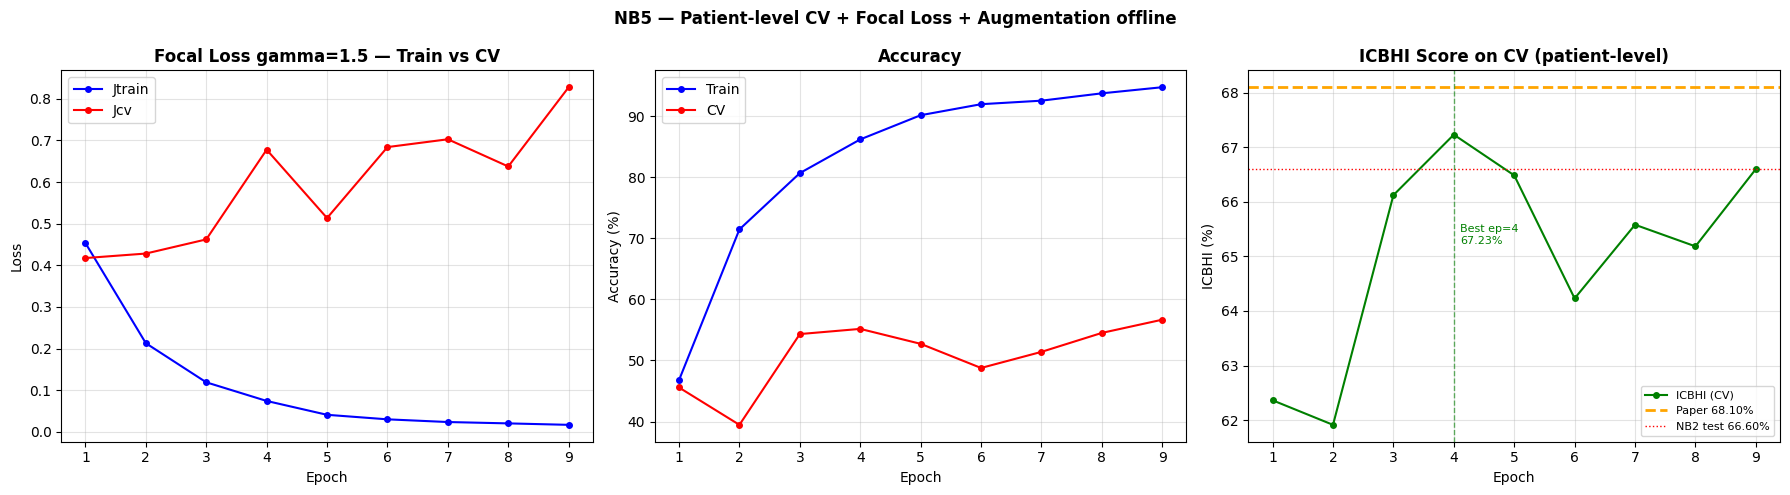

Last epoch: Jtrain=0.0169  Jcv=0.8280  gap=0.8111
Best ICBHI (CV patient-level) : 67.23%  at epoch 4
NB4 CV ICBHI was 79.46% (leaked) — this score is the real one
NB2 gap was 0.2272 — compare to check overfitting


In [9]:
import json, numpy as np, matplotlib.pyplot as plt

with open(HISTORY_FILE) as f:
    history = json.load(f)

epochs_ran = list(range(1, len(history['train_loss'])+1))
fig, axes  = plt.subplots(1, 3, figsize=(18, 5))


ax = axes[0]
ax.plot(epochs_ran, history['train_loss'], 'b-o', label='Jtrain', markersize=4)
ax.plot(epochs_ran, history['cv_loss'],    'r-o', label='Jcv',    markersize=4)
ax.set_title('Focal Loss gamma=1.5 — Train vs CV', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(alpha=0.35)

ax = axes[1]
ax.plot(epochs_ran, [a*100 for a in history['train_acc']], 'b-o', label='Train', markersize=4)
ax.plot(epochs_ran, [a*100 for a in history['cv_acc']],   'r-o', label='CV',    markersize=4)
ax.set_title('Accuracy', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
ax.legend(); ax.grid(alpha=0.35)

ax = axes[2]
ax.plot(epochs_ran, [s*100 for s in history['icbhi_score']], 'g-o', markersize=4, label='ICBHI (CV)')
ax.axhline(68.10, color='orange', lw=2, ls='--', label='Paper 68.10%')
ax.axhline(66.60, color='red',    lw=1, ls=':',  label='NB2 test 66.60%')
best_ep  = int(np.argmax(history['icbhi_score']))+1
best_val = max(history['icbhi_score'])*100
ax.axvline(best_ep, color='green', lw=1, ls='--', alpha=0.6)
ax.text(best_ep+0.1, best_val-2, f'Best ep={best_ep}\n{best_val:.2f}%', fontsize=8, color='green')
ax.set_title('ICBHI Score on CV (patient-level)', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('ICBHI (%)')
ax.legend(fontsize=8); ax.grid(alpha=0.35)

plt.suptitle('NB5 — Patient-level CV + Focal Loss + Augmentation offline', fontweight='bold')
plt.tight_layout()
plt.savefig('learning_curves_nb5.png', dpi=150, bbox_inches='tight')
plt.show()

last = -1
gap  = history['cv_loss'][last] - history['train_loss'][last]
print(f'Last epoch: Jtrain={history["train_loss"][last]:.4f}  Jcv={history["cv_loss"][last]:.4f}  gap={gap:.4f}')
print(f'Best ICBHI (CV patient-level) : {best_val:.2f}%  at epoch {best_ep}')
print(f'NB4 CV ICBHI was 79.46% (leaked) — this score is the real one')
print(f'NB2 gap was 0.2272 — compare to check overfitting')

In [10]:
import numpy as np, torch, os
from torch.utils.data import DataLoader
from tqdm import tqdm
from transformers import ASTFeatureExtractor
from src.dataset import ASTDataset
from src.model   import CustomAST

raw    = np.load(NPZ_PATH)
X_test = raw['X_test']; y_test = raw['y_test']; d_test = raw['device_test']

processor = ASTFeatureExtractor.from_pretrained('MIT/ast-finetuned-audioset-10-10-0.4593')
model     = CustomAST(num_classes=4).to(DEVICE)
model.load_state_dict(torch.load(BEST_CKPT, map_location=DEVICE, weights_only=False))
model.eval()
print(f'Best model loaded: {BEST_CKPT}')

test_loader = DataLoader(
    ASTDataset(X_test, y_test, d_test, processor, train=False),
    batch_size=8, shuffle=False, num_workers=2, pin_memory=True
)

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for inputs, labels, _ in tqdm(test_loader, desc='Test inference', ncols=80):
        logits = model(inputs.to(DEVICE))
        all_preds.extend(logits.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(torch.softmax(logits,dim=1).cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)
np.save(f'{CKPT_DIR}/test_preds.npy',  all_preds)
np.save(f'{CKPT_DIR}/test_labels.npy', all_labels)
np.save(f'{CKPT_DIR}/test_probs.npy',  all_probs)

test_icbhi = icbhi_score(all_labels, all_preds)
print(f'\nTest ICBHI (argmax)  : {test_icbhi*100:.2f}%')
print(f'NB4 test ICBHI       : 66.53%   (NB4 CV was inflated at 79.46% — leakage)')
print(f'NB2 test ICBHI       : 66.60%')
print(f'Paper ICBHI          : 68.10%')
print(f'\nPer-class recall (argmax):')
print(f'{"Class":<10} {"NB5":>8} {"NB2":>8} {"NB4":>8} {"Delta vs NB2":>13}')
print('-'*48)
nb2_r = {'Normal':67.3,'Crackle':52.0,'Wheeze':42.2,'Both':39.6}
nb4_r = {'Normal':45.8,'Crackle':73.8,'Wheeze':53.0,'Both':27.2}
for i, n in enumerate(CLASS_NAMES):
    r = (all_preds[all_labels==i]==i).mean()*100
    print(f'{n:<10} {r:>7.1f}% {nb2_r[n]:>7.1f}% {nb4_r[n]:>7.1f}% {r-nb2_r[n]:>+12.1f}%')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ASTModel LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.layernorm.bias   | UNEXPECTED |  | 
classifier.dense.bias       | UNEXPECTED |  | 
classifier.layernorm.weight | UNEXPECTED |  | 
classifier.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Best model loaded: /kaggle/working/ICBHI-AST-SAM/checkpoints/best_model.pth


Test inference: 100%|█████████████████████████| 295/295 [03:18<00:00,  1.49it/s]


Test ICBHI (argmax)  : 65.42%
NB4 test ICBHI       : 66.53%   (NB4 CV was inflated at 79.46% — leakage)
NB2 test ICBHI       : 66.60%
Paper ICBHI          : 68.10%

Per-class recall (argmax):
Class           NB5      NB2      NB4  Delta vs NB2
------------------------------------------------
Normal        65.1%    67.3%    45.8%         -2.2%
Crackle       53.3%    52.0%    73.8%         +1.3%
Wheeze        57.8%    42.2%    53.0%        +15.6%
Both          13.6%    39.6%    27.2%        -26.0%


In [14]:
import os, numpy as np

# Regenerer patient_ids_train.npy depuis le split file (pas besoin de preprocess)
DATA_DIR = None
for root, dirs, files in os.walk('/kaggle/input/'):
    if len([f for f in files if f.endswith('.wav')]) > 100:
        DATA_DIR = root; break

raw         = np.load(NPZ_PATH, mmap_mode='r')
split_lines = open('data/ICBHI_Challenge_train_test.txt').readlines()
train_files = [l.split('\t')[0] for l in split_lines if 'train' in l]

patient_ids_per_cycle = []
for fname in train_files:
    annot_path = os.path.join(DATA_DIR, fname + '.txt')
    if os.path.exists(annot_path):
        with open(annot_path) as af:
            n_cycles = sum(1 for line in af if line.strip())
    else:
        n_cycles = 1
    patient_ids_per_cycle.extend([fname.split('_')[0]] * n_cycles)

patient_ids_per_cycle = np.array(patient_ids_per_cycle)
n = len(raw['X_train'])
patient_ids_per_cycle = patient_ids_per_cycle[:n]

os.makedirs('data', exist_ok=True)
np.save('data/patient_ids_train.npy', patient_ids_per_cycle)
print(f'Done: {len(patient_ids_per_cycle)} cycle IDs saved.')
print(f'Unique patients: {len(np.unique(patient_ids_per_cycle))}')

Done: 4540 cycle IDs saved.
Unique patients: 76


In [15]:
import numpy as np, torch
from torch.utils.data import DataLoader
from tqdm import tqdm
from transformers import ASTFeatureExtractor
from src.dataset import ASTDataset
from src.model   import CustomAST

# Reload model
model = CustomAST(num_classes=4).to(DEVICE)
model.load_state_dict(torch.load(BEST_CKPT, map_location=DEVICE, weights_only=False))
model.eval()
print(f'Model reloaded: {BEST_CKPT}')

# ── Recreate the SAME patient-level CV split as training ──────────────────
raw        = np.load(NPZ_PATH)
X_trainall = raw['X_train']; y_trainall = raw['y_train']; d_trainall = raw['device_train']

# Load patient IDs per CYCLE (same source as Cell 6)
raw_keys = list(raw.keys())
if 'patient_train' in raw_keys:
    patient_per_cycle = raw['patient_train']
else:
    patient_ids_path = 'data/patient_ids_train.npy'
    if not os.path.exists(patient_ids_path):
        raise FileNotFoundError(
            'data/patient_ids_train.npy not found. Rerun Cell 4.'
        )
    patient_per_cycle = np.load(patient_ids_path, allow_pickle=True)

# Reconstruct cv_mask with IDENTICAL seed and ratio as Cell 6
unique_patients = np.unique(patient_per_cycle)
np.random.seed(42)                                      # same seed as Cell 6
n_cv_patients = max(1, int(len(unique_patients) * 0.30)) # same ratio as Cell 6
cv_patients   = set(np.random.choice(unique_patients, n_cv_patients, replace=False))
cv_mask       = np.array([p in cv_patients for p in patient_per_cycle])

X_cv = X_trainall[cv_mask]; y_cv = y_trainall[cv_mask]; d_cv = d_trainall[cv_mask]
print(f'CV set: {len(y_cv)} cycles from {len(cv_patients)} patients (no leakage)')

processor = ASTFeatureExtractor.from_pretrained('MIT/ast-finetuned-audioset-10-10-0.4593')
cv_loader = DataLoader(
    ASTDataset(X_cv, y_cv, d_cv, processor, train=False),
    batch_size=8, shuffle=False, num_workers=2, pin_memory=True
)

cv_probs_list, cv_labels_list = [], []
with torch.no_grad():
    for inputs, labels, _ in tqdm(cv_loader, desc='CV inference', ncols=80):
        logits = model(inputs.to(DEVICE))
        cv_probs_list.extend(torch.softmax(logits,dim=1).cpu().numpy())
        cv_labels_list.extend(labels.numpy())
cv_probs  = np.array(cv_probs_list)
cv_labels = np.array(cv_labels_list)

cv_icbhi_argmax = icbhi_score(cv_labels, cv_probs.argmax(axis=1))
print(f'CV ICBHI (argmax, no leakage): {cv_icbhi_argmax*100:.2f}%')
print('If this is close to test ICBHI the leakage is fixed.')

def optimize_thresholds(labels, probs, max_iters=60):
    thresholds = np.array([0.5, 0.5, 0.5, 0.5], dtype=float)
    best_score = icbhi_score(labels, np.argmax(probs/thresholds, axis=1))
    step = 0.1
    for _ in range(max_iters):
        improved = False
        for c in range(4):
            best_t = thresholds[c]
            for delta in (-step, step):
                new_t = thresholds[c] + delta
                if new_t < 0.05 or new_t > 5.0: continue
                thresholds[c] = new_t
                score = icbhi_score(labels, np.argmax(probs/thresholds, axis=1))
                if score > best_score:
                    best_score = score; best_t = new_t; improved = True
                thresholds[c] = best_t
        if not improved: step *= 0.5
        if step < 1e-4: break
    return thresholds, best_score

print('\nOptimising thresholds on clean CV...')
best_thresholds, best_cv_icbhi = optimize_thresholds(cv_labels, cv_probs)
print(f'Optimal thresholds : {best_thresholds}')
print(f'Best CV ICBHI      : {best_cv_icbhi*100:.2f}%')

all_preds_orig   = np.load(f'{CKPT_DIR}/test_preds.npy')
all_probs_test   = np.load(f'{CKPT_DIR}/test_probs.npy')
all_labels_test  = np.load(f'{CKPT_DIR}/test_labels.npy')
test_preds_tuned = np.argmax(all_probs_test / best_thresholds, axis=1)
np.save(f'{CKPT_DIR}/test_preds_tuned.npy',    test_preds_tuned)
np.save(f'{CKPT_DIR}/best_thresholds_nb5.npy', best_thresholds)

ic_orig  = icbhi_score(all_labels_test, all_preds_orig)*100
ic_tuned = icbhi_score(all_labels_test, test_preds_tuned)*100
print(f'\nTest ICBHI argmax : {ic_orig:.2f}%')
print(f'Test ICBHI tuned  : {ic_tuned:.2f}%   ({ic_tuned-ic_orig:+.2f}%)')
print(f'NB4 tuned was worse (-0.99%) because CV was leaked — here tuning should help or be neutral')
print(f'Paper             : 68.10%')
print(f'\nPer-class recall — argmax vs tuned:')
print(f'{"Class":<10} {"Argmax":>8} {"Tuned":>8} {"Delta":>8}')
print('-'*38)
for i, n in enumerate(CLASS_NAMES):
    r_o = (all_preds_orig[all_labels_test==i]==i).mean()*100
    r_t = (test_preds_tuned[all_labels_test==i]==i).mean()*100
    print(f'{n:<10} {r_o:>7.1f}% {r_t:>7.1f}% {r_t-r_o:>+7.1f}%')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ASTModel LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.layernorm.bias   | UNEXPECTED |  | 
classifier.dense.bias       | UNEXPECTED |  | 
classifier.layernorm.weight | UNEXPECTED |  | 
classifier.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model reloaded: /kaggle/working/ICBHI-AST-SAM/checkpoints/best_model.pth
CV set: 1062 cycles from 22 patients (no leakage)


CV inference: 100%|███████████████████████████| 133/133 [01:36<00:00,  1.38it/s]

CV ICBHI (argmax, no leakage): 67.23%
If this is close to test ICBHI the leakage is fixed.

Optimising thresholds on clean CV...
Optimal thresholds : [0.396875 0.553125 0.3      0.65    ]
Best CV ICBHI      : 68.65%

Test ICBHI argmax : 65.42%
Test ICBHI tuned  : 65.13%   (-0.29%)
NB4 tuned was worse (-0.99%) because CV was leaked — here tuning should help or be neutral
Paper             : 68.10%

Per-class recall — argmax vs tuned:
Class        Argmax    Tuned    Delta
--------------------------------------
Normal        65.1%    70.4%    +5.3%
Crackle       53.3%    40.2%   -13.2%
Wheeze        57.8%    71.9%   +14.1%
Both          13.6%     5.9%    -7.7%


In [18]:
import numpy as np, os
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, classification_report)
from sklearn.preprocessing import label_binarize

all_labels = np.load(f'{CKPT_DIR}/test_labels.npy')
all_probs  = np.load(f'{CKPT_DIR}/test_probs.npy')
tuned_path = f'{CKPT_DIR}/test_preds_tuned.npy'
best_preds = np.load(tuned_path) if os.path.exists(tuned_path) else np.load(f'{CKPT_DIR}/test_preds.npy')
print(f'Using: {"tuned" if os.path.exists(tuned_path) else "argmax"} predictions')

def full_metrics(labels, preds, probs):
    acc  = accuracy_score(labels, preds)
    prec = precision_score(labels, preds, average='macro', zero_division=0)
    rec  = recall_score(labels, preds, average='macro', zero_division=0)
    f1   = f1_score(labels, preds, average='macro', zero_division=0)
    spec = []
    for c in range(4):
        tn = ((preds!=c)&(labels!=c)).sum()
        fp = ((preds==c)&(labels!=c)).sum()
        spec.append(tn/(tn+fp+1e-9))
    sp    = np.mean(spec)
    y_b   = label_binarize(labels, classes=[0,1,2,3])
    roc   = roc_auc_score(y_b, probs, average='macro', multi_class='ovr')
    icbhi = (rec+sp)/2*100
    return acc, prec, rec, sp, f1, roc, icbhi

m = full_metrics(all_labels, best_preds, all_probs)

print('=' * 82)
print('ABLATION TABLE')
print('=' * 82)
print(f'{"Configuration":<36} {"Recall":>8} {"Specif":>8} {"ICBHI":>8} {"Note"}')
print('-' * 82)
ablation = [
    ('NB1 — CE + WeightedSampler',       48.12, 83.32, 65.72, 'baseline'),
    ('NB2 — FocalLoss g=2.0',            50.28, 82.84, 66.60, '+Focal'),
    ('NB4 — FocalLoss+Aug (leaked CV)',   48.45, 82.64, 65.55, 'CV leaked'),
    ('NB5 — patient CV + Aug offline',    m[2]*100, m[3]*100, m[6], 'this notebook'),
    ('Paper (reference)',                 68.31, 67.89, 68.10, 'cible'),
]
for name, rec, sp, icbhi, note in ablation:
    marker = ' ***' if 'ici' in note else ''
    print(f'{name:<36} {rec:>7.2f}% {sp:>7.2f}% {icbhi:>7.2f}%  {note}{marker}')
print('=' * 82)

print(f'\nPer-class recall — NB2 vs NB4 vs NB5 vs Paper:')
print(f'{"Class":<10} {"NB2":>8} {"NB4":>8} {"NB5":>8} {"Paper":>8}')
print('-' * 46)
nb2_r = {'Normal':67.3,'Crackle':52.0,'Wheeze':42.2,'Both':39.6}
nb4_r = {'Normal':45.8,'Crackle':73.8,'Wheeze':53.0,'Both':27.2}
for i, n in enumerate(CLASS_NAMES):
    r = (best_preds[all_labels==i]==i).mean()*100
    print(f'{n:<10} {nb2_r[n]:>7.1f}% {nb4_r[n]:>7.1f}% {r:>7.1f}%  68.31%')

print(f'\n{"="*55}')
print(f'OBJECTIF : Recall > 68.31% et ICBHI > 68.10%')
print(f'{"="*55}')
rec_pct   = m[2]*100
icbhi_pct = m[6]
if rec_pct >= 68.31 and icbhi_pct >= 68.10:
    print(f'PAPER BATTU — Recall={rec_pct:.2f}%  ICBHI={icbhi_pct:.2f}%')
elif icbhi_pct >= 68.10:
    print(f'ICBHI battu ({icbhi_pct:.2f}%) mais Recall ({rec_pct:.2f}%) encore sous 68.31%')
elif rec_pct >= 68.31:
    print(f'Recall battu ({rec_pct:.2f}%) mais ICBHI ({icbhi_pct:.2f}%) encore sous 68.10%')
else:
    print(f'Recall: {rec_pct:.2f}% ({68.31-rec_pct:.2f}% sous paper)')
    print(f'ICBHI:  {icbhi_pct:.2f}% ({68.10-icbhi_pct:.2f}% sous paper)')
print(f'{"="*55}')

print('\n' + '='*68)
print('CLASSIFICATION REPORT — NB5')
print('='*68)
print(classification_report(all_labels, best_preds, target_names=CLASS_NAMES, digits=4))

Using: tuned predictions
ABLATION TABLE
Configuration                          Recall   Specif    ICBHI Note
----------------------------------------------------------------------------------
NB1 — CE + WeightedSampler             48.12%   83.32%   65.72%  baseline
NB2 — FocalLoss g=2.0                  50.28%   82.84%   66.60%  +Focal
NB4 — FocalLoss+Aug (leaked CV)        48.45%   82.64%   65.55%  CV leaked
NB5 — patient CV + Aug offline         47.10%   83.16%   65.13%  this notebook
Paper (reference)                      68.31%   67.89%   68.10%  cible

Per-class recall — NB2 vs NB4 vs NB5 vs Paper:
Class           NB2      NB4      NB5    Paper
----------------------------------------------
Normal        67.3%    45.8%    70.4%  68.31%
Crackle       52.0%    73.8%    40.2%  68.31%
Wheeze        42.2%    53.0%    71.9%  68.31%
Both          39.6%    27.2%     5.9%  68.31%

OBJECTIF : Recall > 68.31% et ICBHI > 68.10%
Recall: 47.10% (21.21% sous paper)
ICBHI:  65.13% (2.97% sous pap

ERROR ANALYSIS — NB5 (patient-level CV + Aug offline + Thresholds)
Total: 2358  Correct: 1374 (58.3%)  Errors: 984 (41.7%)

Per-class error rate:
  Normal   :  396/1340  (29.6%)  -> mostly Wheeze (232x)
  Crackle  :  359/600   (59.8%)  -> mostly Normal (307x)
  Wheeze   :   70/249   (28.1%)  -> mostly Normal (39x)
  Both     :  159/169   (94.1%)  -> mostly Wheeze (126x)

Avg confidence CORRECT : 55.2%
Avg confidence WRONG   : 53.9%
High-conf (>80%) wrong : 48 cases

Per-device error rate:
  AKGC417L    : 1234 samples  error rate 47.6%
  LittC2SE    :  143 samples  error rate 22.4%
  Litt3200    :  174 samples  error rate 65.5%
  Meditron    :  807 samples  error rate 31.1%


/tmp/ipykernel_57/3824747801.py:115: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


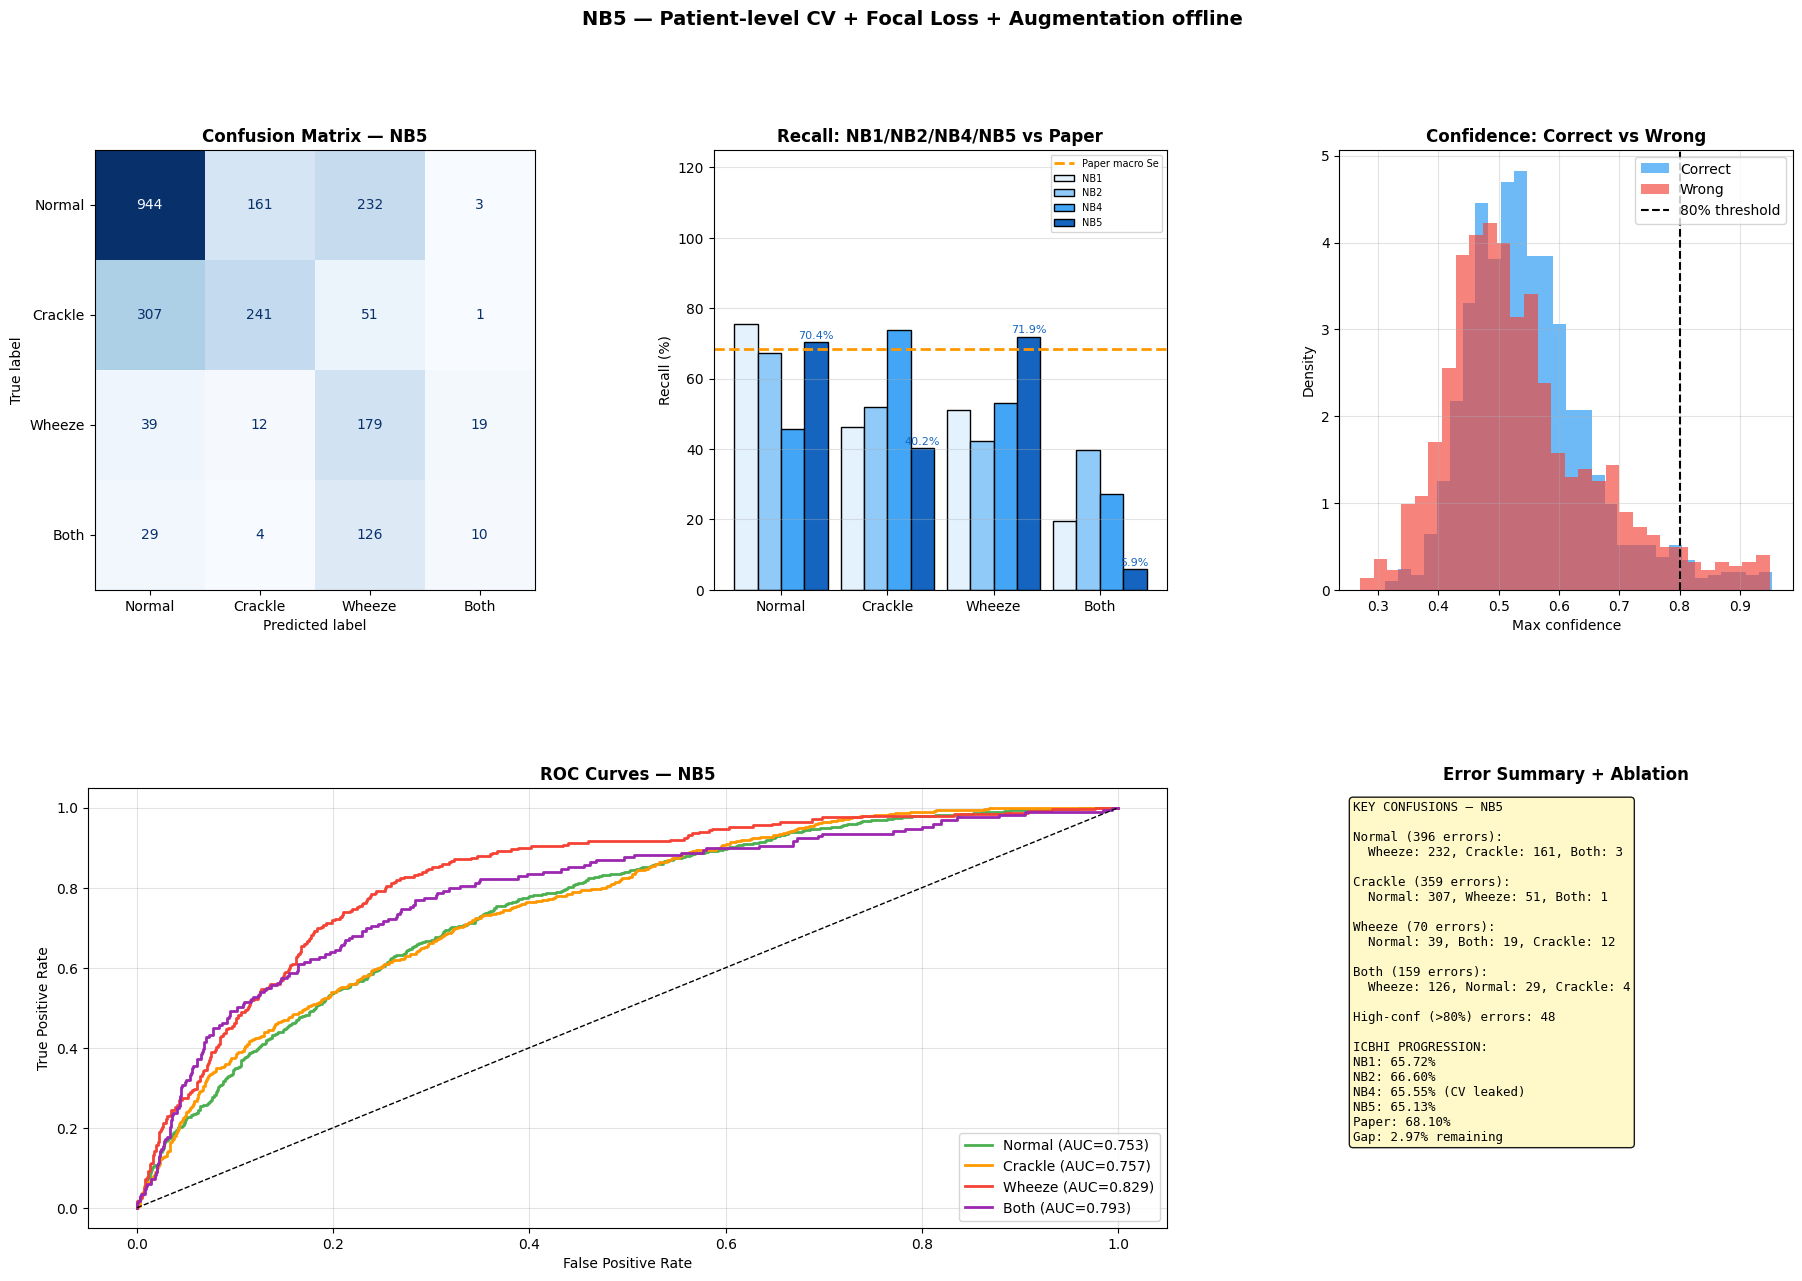

Saved: error_analysis_nb5.png


In [17]:
import numpy as np, matplotlib.pyplot as plt, matplotlib.gridspec as gridspec
from collections import Counter
from sklearn.metrics import roc_curve, auc, ConfusionMatrixDisplay, confusion_matrix
from sklearn.preprocessing import label_binarize
import os

all_labels = np.load(f'{CKPT_DIR}/test_labels.npy')
all_probs  = np.load(f'{CKPT_DIR}/test_probs.npy')
tuned_path = f'{CKPT_DIR}/test_preds_tuned.npy'
best_preds = np.load(tuned_path) if os.path.exists(tuned_path) else np.load(f'{CKPT_DIR}/test_preds.npy')
d_test     = np.load(NPZ_PATH)['device_test']

DEVICE_NAMES = ['AKGC417L','LittC2SE','Litt3200','Meditron']
COLORS       = ['#4CAF50','#FF9800','#F44336','#9C27B0']

errors          = best_preds != all_labels
correct         = ~errors
max_conf        = all_probs.max(axis=1)
high_conf_wrong = errors & (max_conf > 0.80)

print('='*65)
print('ERROR ANALYSIS — NB5 (patient-level CV + Aug offline + Thresholds)')
print('='*65)
print(f'Total: {len(all_labels)}  Correct: {correct.sum()} ({correct.mean()*100:.1f}%)  Errors: {errors.sum()} ({errors.mean()*100:.1f}%)')
print('\nPer-class error rate:')
for i, name in enumerate(CLASS_NAMES):
    mask  = all_labels == i
    n_err = (best_preds[mask] != i).sum()
    mc    = Counter(best_preds[mask & errors]).most_common(1)
    mc_s  = f'-> mostly {CLASS_NAMES[mc[0][0]]} ({mc[0][1]}x)' if mc else ''
    print(f'  {name:<9}: {n_err:>4}/{mask.sum():<5} ({n_err/mask.sum()*100:.1f}%)  {mc_s}')
print(f'\nAvg confidence CORRECT : {max_conf[correct].mean()*100:.1f}%')
print(f'Avg confidence WRONG   : {max_conf[errors].mean()*100:.1f}%')
print(f'High-conf (>80%) wrong : {high_conf_wrong.sum()} cases')
print('\nPer-device error rate:')
for d, dname in enumerate(DEVICE_NAMES):
    m = d_test == d
    if not m.any(): continue
    print(f'  {dname:<12}: {m.sum():>4} samples  error rate {(best_preds[m]!=all_labels[m]).mean()*100:.1f}%')

fig = plt.figure(figsize=(22, 14))
gs  = gridspec.GridSpec(2, 3, hspace=0.45, wspace=0.38)

ax1 = fig.add_subplot(gs[0,0])
cm  = confusion_matrix(all_labels, best_preds)
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(ax=ax1, colorbar=False, cmap='Blues')
ax1.set_title('Confusion Matrix — NB5', fontweight='bold')

ax2 = fig.add_subplot(gs[0,1])
x = np.arange(4); w = 0.22
nb1_r = [75.60, 46.33, 51.00, 19.53]
nb2_r = [67.30, 52.00, 42.20, 39.60]
nb4_r = [45.80, 73.80, 53.00, 27.20]
nb5_r = [(best_preds[all_labels==i]==i).mean()*100 for i in range(4)]
ax2.bar(x-1.5*w, nb1_r, w, label='NB1',  color='#E3F2FD', edgecolor='black')
ax2.bar(x-0.5*w, nb2_r, w, label='NB2',  color='#90CAF9', edgecolor='black')
ax2.bar(x+0.5*w, nb4_r, w, label='NB4',  color='#42A5F5', edgecolor='black')
ax2.bar(x+1.5*w, nb5_r, w, label='NB5',  color='#1565C0', edgecolor='black')
ax2.axhline(68.31, color='#FF9800', lw=2, ls='--', label='Paper macro Se')
for i, v in enumerate(nb5_r):
    ax2.text(x[i]+1.5*w, v+1, f'{v:.1f}%', ha='center', fontsize=8, color='#1565C0')
ax2.set_xticks(x); ax2.set_xticklabels(CLASS_NAMES)
ax2.set_ylabel('Recall (%)'); ax2.set_ylim(0, 125)
ax2.set_title('Recall: NB1/NB2/NB4/NB5 vs Paper', fontweight='bold')
ax2.legend(fontsize=7); ax2.grid(axis='y', alpha=0.35)

ax3 = fig.add_subplot(gs[0,2])
ax3.hist(max_conf[correct], bins=30, alpha=0.65, color='#2196F3', label='Correct', density=True)
ax3.hist(max_conf[errors],  bins=30, alpha=0.65, color='#F44336', label='Wrong',   density=True)
ax3.axvline(0.8, color='black', ls='--', lw=1.5, label='80% threshold')
ax3.set_xlabel('Max confidence'); ax3.set_ylabel('Density')
ax3.set_title('Confidence: Correct vs Wrong', fontweight='bold')
ax3.legend(); ax3.grid(alpha=0.35)

ax4  = fig.add_subplot(gs[1,0:2])
y_bin = label_binarize(all_labels, classes=[0,1,2,3])
for i, (name, color) in enumerate(zip(CLASS_NAMES, COLORS)):
    fpr, tpr, _ = roc_curve(y_bin[:,i], all_probs[:,i])
    ax4.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc(fpr,tpr):.3f})')
ax4.plot([0,1],[0,1],'k--',lw=1)
ax4.set_xlabel('False Positive Rate'); ax4.set_ylabel('True Positive Rate')
ax4.set_title('ROC Curves — NB5', fontweight='bold')
ax4.legend(loc='lower right'); ax4.grid(alpha=0.35)

ax5 = fig.add_subplot(gs[1,2])
ax5.axis('off')
lines = ['KEY CONFUSIONS — NB5\n']
for i, name in enumerate(CLASS_NAMES):
    m = (all_labels==i) & errors
    if not m.any(): continue
    confused = Counter(best_preds[m])
    detail   = ', '.join(f'{CLASS_NAMES[k]}: {v}' for k,v in confused.most_common())
    lines.append(f'{name} ({m.sum()} errors):')
    lines.append(f'  {detail}\n')
lines.append(f'High-conf (>80%) errors: {high_conf_wrong.sum()}')
lines.append('')
lines.append('ICBHI PROGRESSION:')
lines.append('NB1: 65.72%')
lines.append('NB2: 66.60%')
lines.append('NB4: 65.55% (CV leaked)')
icbhi_nb5 = icbhi_score(all_labels, best_preds)*100
lines.append(f'NB5: {icbhi_nb5:.2f}%')
lines.append('Paper: 68.10%')
if icbhi_nb5 >= 68.10:
    lines.append('>>> PAPER BATTU <<<')
else:
    lines.append(f'Gap: {68.10-icbhi_nb5:.2f}% remaining')
ax5.text(0.03, 0.97, '\n'.join(lines), ha='left', va='top', fontsize=9,
         family='monospace',
         bbox=dict(boxstyle='round', facecolor='#FFF9C4', alpha=0.9),
         transform=ax5.transAxes)
ax5.set_title('Error Summary + Ablation', fontweight='bold')

plt.suptitle('NB5 — Patient-level CV + Focal Loss + Augmentation offline', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('error_analysis_nb5.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: error_analysis_nb5.png')